# Install & Import

In [ ]:
!pip install transformers-interpret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have 

In [ ]:
import sys, subprocess, importlib, re, math, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import wandb
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

from transformers import AutoTokenizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    MarianMTModel, MarianTokenizer, get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from transformers_interpret import SequenceClassificationExplainer
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
import time
from datetime import datetime
import os
import gc
import gdown

url = "https://drive.google.com/drive/folders/1V3Jy2FbjO0cAlYv5cWZW16E0GtMhF5QB?usp=sharing"
gdown.download_folder(
    url,
    output='/content/',
    quiet=False,
    use_cookies=False,
    remaining_ok=True
)


CKPT_DIR = '/content/DL/'
os.makedirs(CKPT_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# EDA

## Load dataset

In [ ]:
file_path = '/content/DL/oregon_real_estate_2026_ultimate.csv'
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]
display(df.head())

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,"Showings subject to accepted offer. Investor opportunity in Cathedral Park on a nearly 10,000 sq ft CM3-zoned lot. P...",179950.0,698.0,1.0,2.0,1.0,1.0,1.0,NaN,1897.0
1,single_family,NaN,"*DO NOT DRIVE BY WITHOUT AN APPOINTMENT* Distressed property due to land movement, drainage and foundation damage. T...",399900.0,2736.0,2.0,4.0,2.0,2.0,2.0,2.0,1990.0
2,condos,condo,This exceptional property is priced to sell & is a must-see for fly fishing enthusiasts. One-quarter shared interest...,220000.0,1130.0,1.0,3.0,3.0,3.0,3.0,NaN,2011.0
3,single_family,NaN,Commercially zoned property currently utilized as a residence with flexible living space. The upper level functions ...,230000.0,1293.0,2.0,3.0,2.0,2.0,2.0,1.0,1956.0
4,condos,condo,Sophisticated and beautifully updated riverfront townhome in an exceptional location just steps from the Willamette ...,899000.0,3172.0,3.0,3.0,4.0,4.0,4.0,1.0,2006.0


## Cleaning text and lable (DROP NA)

In [ ]:
# ============================================================
# 2) Clean target and text
# ============================================================
display(Markdown("## 2. Label & Text Cleaning"))

before_rows = len(df)
df = df.dropna(subset=["type", "text"]).copy()
df["type"] = df["type"].astype(str).str.strip().str.lower()
df["text"] = df["text"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["text"].ne("")].copy()
after_rows = len(df)

cleaning_summary = pd.DataFrame({
    "": ["Before cleaning", "After cleaning", "Rows removed", "Unique labels"],
    "Value": [before_rows, after_rows, before_rows - after_rows, df["type"].nunique()]
})
display(cleaning_summary.set_index(""))

label_counts = df["type"].value_counts()
display(label_counts.to_frame("count"))

## 2. Label & Text Cleaning

,Value
,
Before cleaning,10403
After cleaning,10384
Rows removed,19
Unique labels,8


,count
type,
single_family,6545
land,1868
condos,858
townhomes,496
multi_family,411
farm,192
townhome,8
unknown,6


## 3. Label Distribution

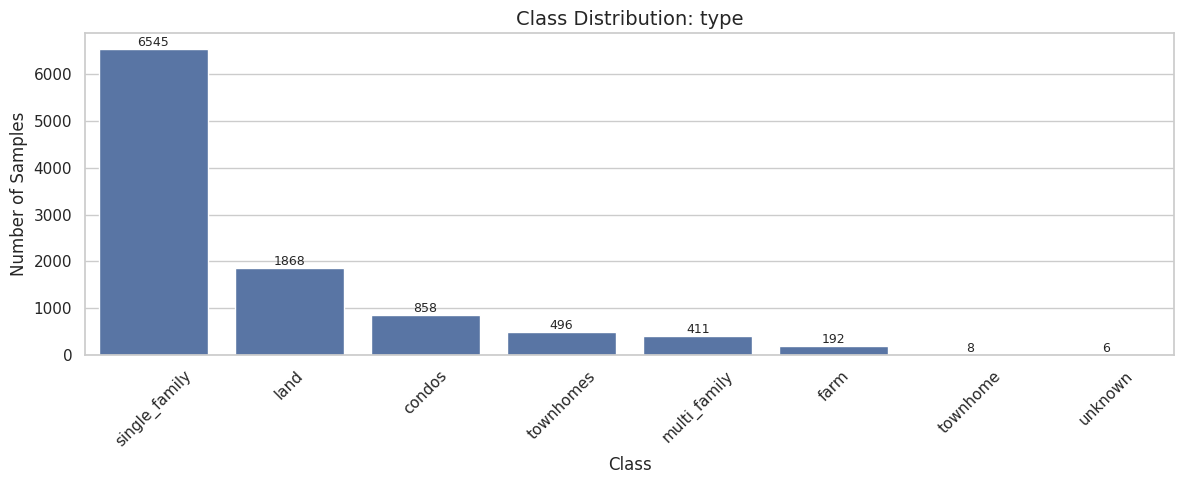

,class,count,class_weight
0,single_family,6545,0.1983
1,land,1868,0.6949
2,condos,858,1.5128
3,townhomes,496,2.6169
4,multi_family,411,3.1582
5,farm,192,6.7604
6,townhome,8,162.2500
7,unknown,6,216.3333


In [ ]:
# ============================================================
# 3) Label distribution
# ============================================================
display(Markdown("## 3. Label Distribution"))

fig, ax = plt.subplots(figsize=(12, 5))
order = label_counts.index.tolist()
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title("Class Distribution: type", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Samples")
ax.tick_params(axis="x", rotation=45)
for i, v in enumerate(label_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

imbalance_ratio = label_counts.max() / label_counts.min()
n_classes = df["type"].nunique()
total = len(df)
class_weights = {cls: total / (n_classes * cnt) for cls, cnt in label_counts.items()}
class_weights_df = pd.DataFrame({
    "class": list(class_weights.keys()),
    "count": [label_counts[c] for c in class_weights.keys()],
    "class_weight": [round(class_weights[c], 4) for c in class_weights.keys()]
}).sort_values("count", ascending=False).reset_index(drop=True)
display(class_weights_df)

## 4. Missing Values by Class

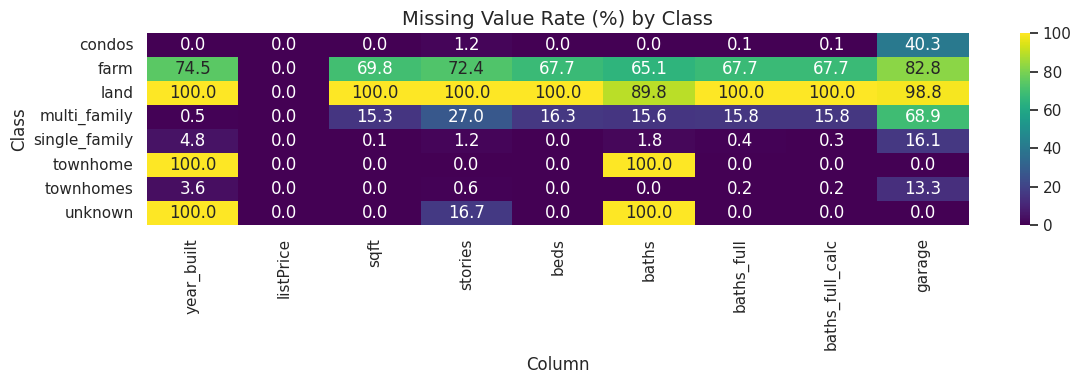

In [ ]:
# ============================================================
# 4) Missing-value analysis by label
# ============================================================
display(Markdown("## 4. Missing Values by Class"))

numeric_cols = [
    "year_built", "listPrice", "sqft", "stories", "beds", "baths",
    "baths_full", "baths_full_calc", "garage"
]
existing_numeric_cols = [c for c in numeric_cols if c in df.columns]

if existing_numeric_cols:
    missing_by_class = (
        df.groupby("type")[existing_numeric_cols]
          .apply(lambda g: g.isna().mean() * 100)
          .round(1)
    )
    # display(missing_by_class)

    plt.figure(figsize=(12, max(4, 0.45 * len(missing_by_class))))
    sns.heatmap(missing_by_class, annot=True, fmt=".1f", cmap="viridis")
    plt.title("Missing Value Rate (%) by Class", fontsize=14)
    plt.xlabel("Column")
    plt.ylabel("Class")
    plt.tight_layout()
    plt.show()

## 5. Text Length Analysis

,percentile,char_len,word_len
0,0%,8.00,2.0
1,50%,809.00,131.0
2,75%,1084.00,174.0
3,90%,1551.00,246.0
4,95%,1828.85,288.0
5,99%,1996.17,325.0
6,100%,4001.00,628.0


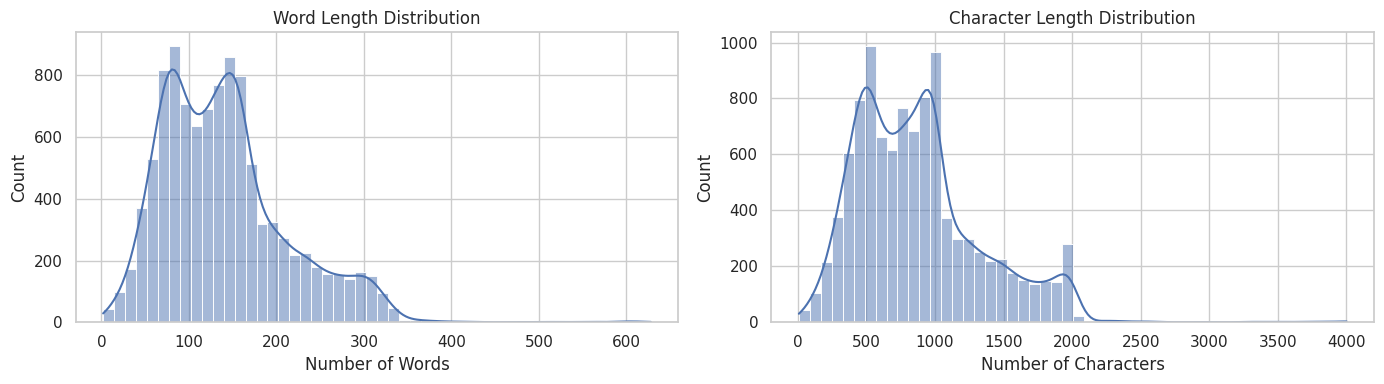

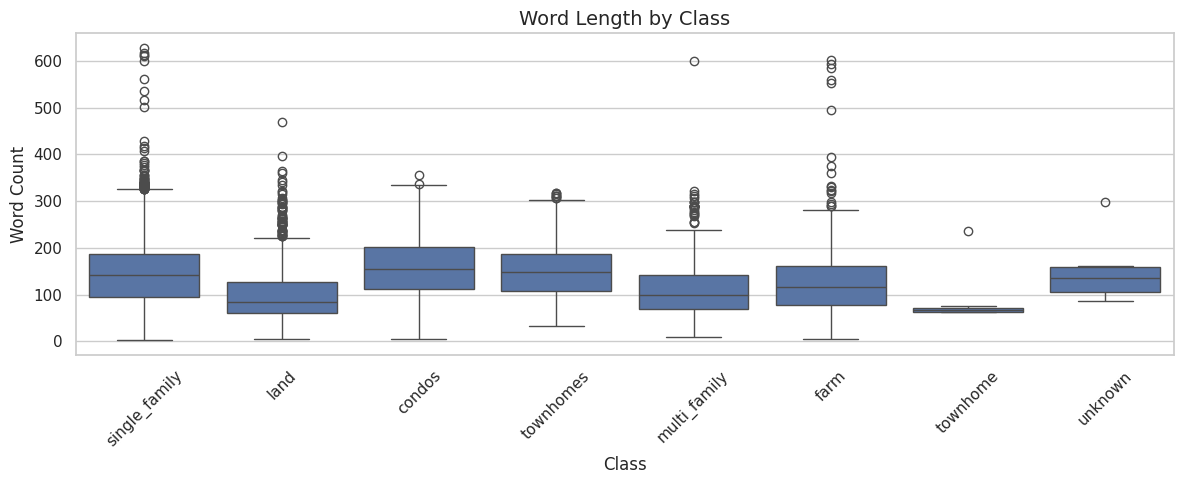

In [ ]:
# ============================================================
# 5) Text length analysis
# ============================================================
display(Markdown("## 5. Text Length Analysis"))

TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
STOPWORDS = set(ENGLISH_STOP_WORDS)

def basic_tokens(text: str):
    return TOKEN_RE.findall(str(text).lower())

def aggressive_preprocess(text: str):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOPWORDS]
    return " ".join(tokens)

df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].apply(lambda x: len(basic_tokens(x)))

# percentiles = [min, 0.5, 0.75, 0.9, 0.95, 0.99]
# text_len_summary = pd.DataFrame({
#     "percentile": [f"{int(p*100)}%" for p in percentiles],
#     "char_len": [df["char_len"].quantile(p) for p in percentiles],
#     "word_len": [df["word_len"].quantile(p) for p in percentiles],
# })
percentiles = [0, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

text_len_summary = pd.DataFrame({
    "percentile": [f"{int(p*100)}%" for p in percentiles],
    "char_len": [df["char_len"].quantile(p) for p in percentiles],
    "word_len": [df["word_len"].quantile(p) for p in percentiles],
})

# Add min and max
# extra = pd.DataFrame({
#     "percentile": ["min", "max"],
#     "char_len": [df["char_len"].min(), df["char_len"].max()],
#     "word_len": [df["word_len"].min(), df["word_len"].max()],
# })

# text_len_summary = pd.concat([extra, text_len_summary], ignore_index=True)
display(text_len_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["word_len"], bins=50, ax=axes[0], kde=True)
axes[0].set_title("Word Length Distribution")
axes[0].set_xlabel("Number of Words")

sns.histplot(df["char_len"], bins=50, ax=axes[1], kde=True)
axes[1].set_title("Character Length Distribution")
axes[1].set_xlabel("Number of Characters")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="type", y="word_len", ax=ax, order=label_counts.index)
ax.set_title("Word Length by Class", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Word Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# word_p50 = df["word_len"].quantile(0.50)
# word_p95 = df["word_len"].quantile(0.95)
# word_p99 = df["word_len"].quantile(0.99)

# if word_p95 <= 64:
#     recommended_lstm_max_len = 64
# elif word_p95 <= 128:
#     recommended_lstm_max_len = 128
# elif word_p95 <= 256:
#     recommended_lstm_max_len = 256
# else:
#     recommended_lstm_max_len = 512

# spread_ratio = word_p95 / max(word_p50, 1)

In [ ]:
# ============================================================
# 6) Train / val / test split
# ============================================================
display(Markdown("## 6. Train / Val / Test Split"))

def finalize_label_cleaning(df):
    # Merge townhome into townhomes
    df['type'] = df['type'].replace('townhome', 'townhomes')
    # Drop unknown
    df = df[df['type'] != 'unknown'].reset_index(drop=True)
    return df

model_df = df[["type", "text"]].copy()
final_model_df = finalize_label_cleaning(model_df)
min_class_count = final_model_df["type"].value_counts().min()
use_stratify = min_class_count >= 3
stratify_arg = final_model_df["type"] if use_stratify else None

train_df, temp_df = train_test_split(
    final_model_df, test_size=0.20, random_state=42, stratify=stratify_arg
)
stratify_temp = temp_df["type"] if (use_stratify and temp_df["type"].value_counts().min() >= 2) else None
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=stratify_temp
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

split_sizes = pd.DataFrame({
    "Split": ["Train", "Val", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)]
}).set_index("Split")
display(split_sizes)

def split_summary(df_part, name):
    return df_part["type"].value_counts(normalize=True).mul(100).round(2).rename(name)

split_dist = pd.concat(
    [split_summary(train_df, "train_%"), split_summary(val_df, "val_%"), split_summary(test_df, "test_%")],
    axis=1
).fillna(0)
display(split_dist)

## 6. Train / Val / Test Split

,Rows
Split,
Train,8302
Val,1038
Test,1038


,train_%,val_%,test_%
type,,,
single_family,63.07,63.01,63.10
land,18.00,18.02,18.02
condos,8.26,8.29,8.29
townhomes,4.85,4.91,4.82
multi_family,3.96,3.95,3.95
farm,1.85,1.83,1.83


In [ ]:
# ============================================================
# 7) Compare preprocessing styles
# ============================================================
display(Markdown("## 7. Preprocessing Comparison"))

for part in [train_df, val_df, test_df]:
    part["text_min"]  = part["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    part["text_aggr"] = part["text"].apply(aggressive_preprocess)

def tokenize_series(series):
    return series.apply(basic_tokens)

def corpus_stats(text_series):
    token_lists = tokenize_series(text_series)
    lengths     = token_lists.apply(len)
    all_tokens  = [tok for tokens in token_lists for tok in tokens]
    vocab       = Counter(all_tokens)
    return {
        "num_docs":                    len(text_series),
        "avg_words":                   round(lengths.mean(), 2),
        "median_words":                lengths.median(),
        "p95_words":                   lengths.quantile(0.95),
        "vocab_size":                  len(vocab),
        "rare_tokens_once":            sum(1 for _, c in vocab.items() if c == 1),
        "total_tokens":                len(all_tokens),
        "avg_unique_tokens_per_doc":   round(token_lists.apply(lambda x: len(set(x))).mean(), 2),
    }

raw_stats  = corpus_stats(train_df["text_min"])
aggr_stats = corpus_stats(train_df["text_aggr"])

preprocess_compare = pd.DataFrame([
    {"variant": "minimal",    **raw_stats},
    {"variant": "aggressive", **aggr_stats},
])
display(preprocess_compare)

## 7. Preprocessing Comparison

,variant,num_docs,avg_words,median_words,p95_words,vocab_size,rare_tokens_once,total_tokens,avg_unique_tokens_per_doc
0,minimal,8302,140.10,131.0,287.0,18238,7267,1163094,102.82
1,aggressive,8302,93.04,86.0,190.0,17432,6943,772396,81.52


In [ ]:
# ============================================================
# 8) Word-level vocabulary analysis (train only)
# ============================================================
display(Markdown("## 8. Vocabulary Analysis (Train)"))

train_tokens = [tok for text in train_df["text_min"] for tok in basic_tokens(text)]
val_tokens   = [tok for text in val_df["text_min"]   for tok in basic_tokens(text)]
test_tokens  = [tok for text in test_df["text_min"]  for tok in basic_tokens(text)]

train_counter = Counter(train_tokens)
train_vocab   = set(train_counter.keys())

def oov_rate(tokens, vocab):
    if len(tokens) == 0:
        return np.nan
    return sum(tok not in vocab for tok in tokens) / len(tokens)

oov_val  = oov_rate(val_tokens,  train_vocab)
oov_test = oov_rate(test_tokens, train_vocab)
rare_once  = sum(1 for _, c in train_counter.items() if c == 1)
rare_share = rare_once / max(len(train_counter), 1)

vocab_summary = pd.DataFrame({
    "Metric": [
        "Train unique vocab size",
        "Tokens appearing once",
        "Rare token share (%)",
        "OOV rate — val (%)",
        "OOV rate — test (%)",
    ],
    "Value": [
        len(train_vocab),
        rare_once,
        round(rare_share * 100, 2),
        round(oov_val  * 100, 2),
        round(oov_test * 100, 2),
    ]
}).set_index("Metric")
display(vocab_summary)

freqs        = np.array(sorted(train_counter.values(), reverse=True))
cum_coverage = np.cumsum(freqs) / freqs.sum()

def coverage_at_k(k):
    if len(freqs) == 0:
        return np.nan
    k = min(k, len(freqs))
    return cum_coverage[k - 1]

coverage_ks = [1000, 2000, 5000, 10000, 20000, 30000]
coverage_table = pd.DataFrame({
    "top_k_vocab":              coverage_ks,
    "token_coverage_train_%":   [round(100 * coverage_at_k(k), 2) for k in coverage_ks],
})
display(coverage_table)

recommended_vocab = None
for i, cov in enumerate(cum_coverage, start=1):
    if cov >= 0.95:
        recommended_vocab = i
        break
if recommended_vocab is None:
    recommended_vocab = len(train_counter)

## 8. Vocabulary Analysis (Train)

,Value
Metric,
Train unique vocab size,18238.00
Tokens appearing once,7267.00
Rare token share (%),39.85
OOV rate — val (%),0.69
OOV rate — test (%),0.66


,top_k_vocab,token_coverage_train_%
0,1000,84.76
1,2000,92.28
2,5000,97.54
3,10000,99.21
4,20000,100.00
5,30000,100.00


## 9. Top N-grams per Class (Train)

### `single_family`

,class,ngram,count
0,single_family,home,11204
1,single_family,living,6480
2,single_family,room,6465
3,single_family,space,4406
4,single_family,kitchen,4142


### `land`

,class,ngram,count
0,land,property,1674
1,land,lot,1222
2,land,home,1038
3,land,build,744
4,land,views,689


...

,class,ngram,count
0,townhomes,home,661
1,townhomes,living,512
2,townhomes,room,386
3,townhomes,kitchen,353
4,townhomes,new,321


### `multi_family`

,class,ngram,count
0,multi_family,unit,397
1,multi_family,property,328
2,multi_family,units,312
3,multi_family,opportunity,217
4,multi_family,new,203


### `farm`

,class,ngram,count
0,farm,property,252
1,farm,acres,187
2,farm,water,129
3,farm,ranch,121
4,farm,home,117


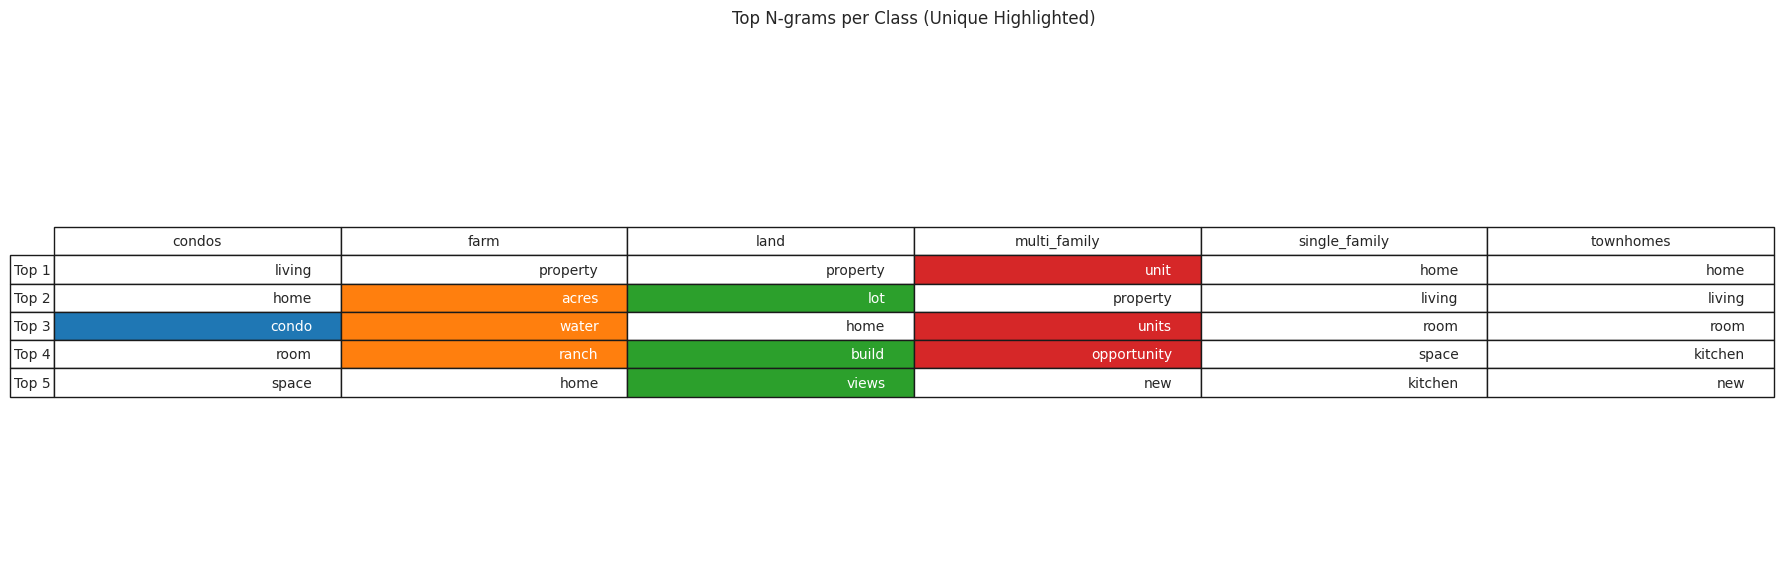

In [ ]:
# ============================================================
# 9) Top n-grams per class
# ============================================================
display(Markdown("## 9. Top N-grams per Class (Train)"))

def top_ngrams_for_class(
    dataframe,
    class_name,
    text_col="text_aggr",
    ngram_range=(1, 2),
    top_n=5,
    min_df=2
):
    subset = dataframe[dataframe["type"] == class_name]
    texts  = subset[text_col].dropna().tolist()

    if len(texts) == 0:
        return pd.DataFrame(columns=["class", "ngram", "count"])

    local_min_df = min(min_df, max(1, len(texts)))

    try:
        vec    = CountVectorizer(ngram_range=ngram_range, min_df=local_min_df)
        X      = vec.fit_transform(texts)
        counts = np.asarray(X.sum(axis=0)).ravel()
        terms  = np.array(vec.get_feature_names_out())

        top_idx = counts.argsort()[::-1][:top_n]

        return pd.DataFrame({
            "class": class_name,
            "ngram": terms[top_idx],
            "count": counts[top_idx]
        })

    except Exception:
        return pd.DataFrame(columns=["class", "ngram", "count"])


# --- compute ---
top_k   = 5
classes = train_df["type"].value_counts().index.tolist()

top_ngram_tables = [
    top_ngrams_for_class(
        train_df,
        cls,
        text_col="text_aggr",
        ngram_range=(1, 2),
        top_n=top_k,
        min_df=2
    )
    for cls in classes
]

top_ngrams_df = pd.concat(top_ngram_tables, ignore_index=True)

# --- display raw tables ---
for cls in classes:
    display(Markdown(f"### `{cls}`"))
    display(
        top_ngrams_df[top_ngrams_df["class"] == cls]
        .reset_index(drop=True)
    )


# ============================================================
# 9.2) Pivot + Highlight unique n-grams
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# --- add rank column BEFORE pivot ---
top_ngrams_df["rank"] = top_ngrams_df.groupby("class").cumcount()

# --- pivot using the new rank column ---
pivot_df = top_ngrams_df.pivot(
    index="rank",
    columns="class",
    values="ngram"
)

pivot_df = pivot_df.head(top_k).reset_index(drop=True)

# --- find unique n-grams ---
ngram_class_count = (
    top_ngrams_df.groupby("ngram")["class"]
    .nunique()
)

unique_ngrams = set(
    ngram_class_count[ngram_class_count == 1].index
)

# --- assign colors per class ---
colors = list(mcolors.TABLEAU_COLORS.values())
class_color_map = {
    cls: colors[i % len(colors)]
    for i, cls in enumerate(pivot_df.columns)
}

# ============================================================
# Plot table
# ============================================================
fig, ax = plt.subplots(
    figsize=(len(pivot_df.columns) * 3, top_k * 1.2)
)
ax.axis('off')

table = ax.table(
    cellText=pivot_df.values,
    colLabels=pivot_df.columns,
    rowLabels=[f"Top {i+1}" for i in range(len(pivot_df))],
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# --- highlight unique n-grams ---
for (row, col), cell in table.get_celld().items():
    if row == 0:          # header row → skip
        continue
    if col == -1:         # row-label column → skip
        continue

    row_idx = row - 1
    col_idx = col

    if row_idx >= len(pivot_df) or col_idx >= len(pivot_df.columns):
        continue

    ngram = pivot_df.iloc[row_idx, col_idx]
    cls   = pivot_df.columns[col_idx]

    if pd.notna(ngram) and ngram in unique_ngrams:
        cell.set_facecolor(class_color_map[cls])
        cell.set_text_props(color='white')

plt.title("Top N-grams per Class (Unique Highlighted)", pad=20)
plt.tight_layout()
plt.show()

## 10. Transformer Tokenization Stats

Token indices sequence length is longer than the specified maximum sequence length for this model (646 > 512). Running this sequence through the model will result in indexing errors


,split,avg_subwords,p50_subwords,p95_subwords,p99_subwords,max_subwords
0,train,179.70,166.0,366.0,421.00,898
1,val,183.52,171.5,385.0,435.89,828
2,test,180.45,170.5,363.0,415.52,769


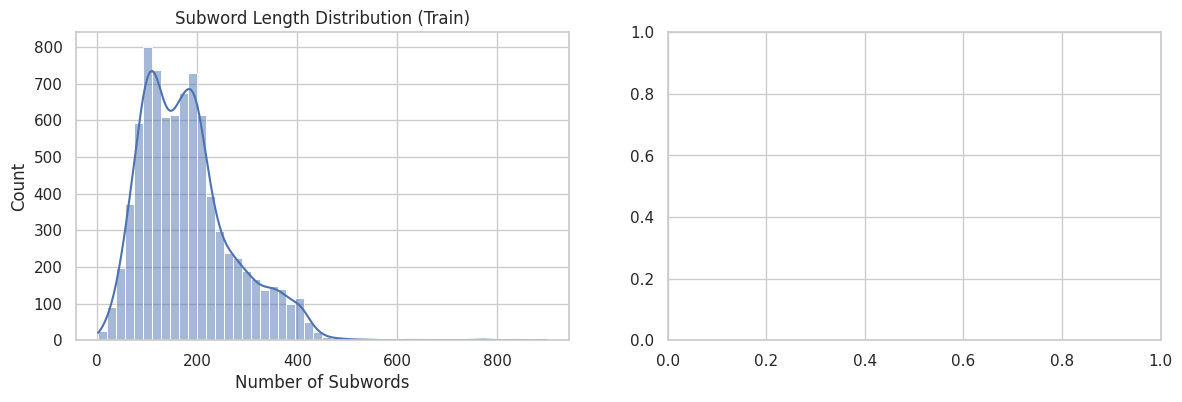

In [ ]:
# ============================================================
# 10) Transformer tokenization stats
# ============================================================
display(Markdown("## 10. Transformer Tokenization Stats"))

try:
    tokenizer_name = "bert-base-uncased"
    tokenizer      = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=True)

    def subword_lengths(texts):
        enc = tokenizer(list(texts), add_special_tokens=False, padding=False, truncation=False)
        return np.array([len(ids) for ids in enc["input_ids"]], dtype=int)

    train_sub_len = subword_lengths(train_df["text_min"])
    val_sub_len   = subword_lengths(val_df["text_min"])
    test_sub_len  = subword_lengths(test_df["text_min"])

    subword_stats = pd.DataFrame({
        "split":        ["train", "val", "test"],
        "avg_subwords": [train_sub_len.mean(), val_sub_len.mean(), test_sub_len.mean()],
        "p50_subwords": [np.quantile(s, 0.50) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "p95_subwords": [np.quantile(s, 0.95) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "p99_subwords": [np.quantile(s, 0.99) for s in [train_sub_len, val_sub_len, test_sub_len]],
        "max_subwords": [s.max() for s in [train_sub_len, val_sub_len, test_sub_len]],
    }).round(2)
    display(subword_stats)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(train_sub_len, bins=50, ax=axes[0], kde=True)
    axes[0].set_title("Subword Length Distribution (Train)")
    axes[0].set_xlabel("Number of Subwords")

    sns.histplot(train_sub_len / np.maximum(train_df["word_len"].values, 1), bins=50, ax=axes[1], kde=True)
    axes[1].set_title("Subword-to-Word Ratio (Train)")
    axes[1].set_xlabel("Subwords / Words")
    plt.tight_layout()
    plt.show()

    subword_p50 = np.quantile(train_sub_len, 0.50)
    subword_p95 = np.quantile(train_sub_len, 0.95)
    subword_p99 = np.quantile(train_sub_len, 0.99)
    subword_ratio = subword_p95 / max(subword_p50, 1)

    if subword_p95 <= 64:
        recommended_transformer_max_len = 64
    elif subword_p95 <= 128:
        recommended_transformer_max_len = 128
    elif subword_p95 <= 256:
        recommended_transformer_max_len = 256
    else:
        recommended_transformer_max_len = 512

except Exception as e:
    recommended_transformer_max_len = None

In [ ]:
# # ============================================================
# # 11) EDA-driven recommendation summary
# # ============================================================
# display(Markdown("## 11. EDA Summary & Recommendations"))

# oov_avg      = np.nanmean([oov_val, oov_test])
# word_len_tail = word_p95 / max(word_p50, 1)

# summary_rows = {
#     "Number of classes":                     df["type"].nunique(),
#     "Imbalance ratio (max/min)":             round(imbalance_ratio, 2),
#     "Avg OOV rate — val/test (%)":           round(oov_avg * 100, 2),
#     "Train vocab size":                      len(train_vocab),
#     "Recommended RNN embedding vocab size":  recommended_vocab,
#     "Recommended LSTM max_length (words)":   recommended_lstm_max_len,
# }
# if recommended_transformer_max_len is not None:
#     summary_rows["Recommended Transformer max_length"] = recommended_transformer_max_len

# summary_df = pd.DataFrame.from_dict(summary_rows, orient="index", columns=["Value"])
# display(summary_df)

# recs = []
# recs.append(
#     "✅ Use class weights in loss function."
#     if imbalance_ratio >= 2 else
#     "ℹ️ Class weights optional — worth testing."
# )
# recs.append(
#     "✅ Large/noisy vocabulary → Transformer is likely the stronger first choice."
#     if (len(train_vocab) >= 30000 or oov_avg >= 0.08) else
#     "ℹ️ Manageable vocabulary → a well-tuned BiLSTM can be a strong baseline."
# )
# recs.append(
#     "✅ Text length varies substantially → dynamic padding / bucketing recommended."
#     if word_len_tail > 2.5 else
#     "ℹ️ Text lengths concentrated → a single fixed max_length is sufficient."
# )

# recs_df = pd.DataFrame({"Recommendation": recs})
# display(recs_df)

# next_steps_df = pd.DataFrame({
#     "#": [1, 2, 3],
#     "Experiment": [
#         "BiLSTM/GRU with embedding_dim 100–300, bidirectional=True, dropout 0.2–0.5",
#         "Transformer fine-tuning with EDA-derived max_length, batch_size 8–16",
#         "Compare weighted cross-entropy vs unweighted cross-entropy",
#     ]
# }).set_index("#")
# display(Markdown("### Suggested Next Experiments"))
# display(next_steps_df)

## Label Encoding

In [ ]:
# train_df = finalize_label_cleaning(train_df)
# val_df = finalize_label_cleaning(val_df)
# test_df = finalize_label_cleaning(test_df)

# Encode labels to integers
unique_labels = sorted(train_df["type"].unique())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_classes = len(unique_labels)

for df_split in [train_df, val_df, test_df]:
    df_split["label"] = df_split["type"].map(label2id)

# Create class weights tensor aligned with label2id
# (class_weights dict was calculated in EDA Step 3)
weight_list = [class_weights[id2label[i]] for i in range(num_classes)]
class_weights_tensor = torch.tensor(weight_list, dtype=torch.float).to(device)

print("Label Mapping:", label2id)
print("Class Weights Tensor:", class_weights_tensor)

Label Mapping: {'condos': 0, 'farm': 1, 'land': 2, 'multi_family': 3, 'single_family': 4, 'townhomes': 5}
Class Weights Tensor: tensor([1.5128, 6.7604, 0.6949, 3.1582, 0.1983, 2.6169], device='cuda:0')


## Minority Class Augmentation (Back-Translation)

In [ ]:
AUG_DATA_PATH = os.path.join(CKPT_DIR, 'train_df_augmented.parquet')

def run_augmentation_pipeline(df, text_col, minority_classes, num_samples_per_class=150):
    print("Loading MarianMT models for English <-> German...")

    en_de_model_name = "Helsinki-NLP/opus-mt-en-de"
    de_en_model_name = "Helsinki-NLP/opus-mt-de-en"

    tokenizer_en_de = MarianTokenizer.from_pretrained(en_de_model_name)
    model_en_de = MarianMTModel.from_pretrained(en_de_model_name).to(device)

    tokenizer_de_en = MarianTokenizer.from_pretrained(de_en_model_name)
    model_de_en = MarianMTModel.from_pretrained(de_en_model_name).to(device)

    augmented_rows = []

    for cls in minority_classes:
        subset = df[df["type"] == cls]
        # Limiting samples to manage Colab time
        subset = subset.sample(n=min(len(subset), num_samples_per_class), random_state=42)

        texts = subset[text_col].tolist()
        batch_size = 16

        print(f"Augmenting {len(texts)} samples for class '{cls}'...")
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i+batch_size]

            # EN -> DE
            encoded_en = tokenizer_en_de(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
            translated_de = model_en_de.generate(**encoded_en)
            de_texts = [tokenizer_en_de.decode(t, skip_special_tokens=True) for t in translated_de]

            # DE -> EN
            encoded_de = tokenizer_de_en(de_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
            back_translated_en = model_de_en.generate(**encoded_de)
            en_texts = [tokenizer_de_en.decode(t, skip_special_tokens=True) for t in back_translated_en]

            for orig_row, new_text in zip(subset.iloc[i:i+batch_size].itertuples(), en_texts):
                augmented_rows.append({
                    "type": orig_row.type,
                    text_col: new_text,
                    "label": orig_row.label
                })

    # Free up GPU memory
    del model_en_de, model_de_en
    torch.cuda.empty_cache()
    gc.collect()

    aug_df_only = pd.DataFrame(augmented_rows)
    final_train_aug = pd.concat([df, aug_df_only], ignore_index=True)

    return final_train_aug

# --- Smart Load Logic ---
if os.path.exists(AUG_DATA_PATH):
    print(f"Found saved augmented data! Loading from {AUG_DATA_PATH}...")
    train_df_aug = pd.read_parquet(AUG_DATA_PATH)
    # Ensure labels are integers after loading from CSV
    train_df_aug["label"] = train_df_aug["label"].astype(int)
    print(f"Successfully loaded {len(train_df_aug)} rows.")
else:
    print(f"No saved data found at {AUG_DATA_PATH}. Running augmentation from scratch...")
    minority_targets = ['farm', 'multi_family', 'townhomes', 'condos']
    train_df_aug = run_augmentation_pipeline(train_df, "text_min", minority_targets, num_samples_per_class=150)

    # Save to CSV for future use
    train_df_aug.to_parquet(AUG_DATA_PATH, index=False)
    print(f"Augmentation complete. Saved {len(train_df_aug)} rows to {AUG_DATA_PATH}")

# --- Generate Aggressive Text if Missing ---
# Ensure 'text_aggr' exists for the ablation matrix experiments
if "text_aggr" not in train_df_aug.columns or train_df_aug["text_aggr"].isna().any():
    print("Generating 'text_aggr' for augmented data...")
    train_df_aug["text_aggr"] = train_df_aug["text_min"].apply(aggressive_preprocess)
    # Resave the CSV so the new column is there for next time
    train_df_aug.to_parquet(AUG_DATA_PATH, index=False)
    print("Updated saved CSV with 'text_aggr' column.")

No saved data found at /content/DL/train_df_augmented.parquet. Running augmentation from scratch...
Loading MarianMT models for English <-> German...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Augmenting 150 samples for class 'farm'...
Augmenting 150 samples for class 'multi_family'...
Augmenting 150 samples for class 'townhomes'...
Augmenting 150 samples for class 'condos'...
Augmentation complete. Saved 8902 rows to /content/DL/train_df_augmented.parquet
Generating 'text_aggr' for augmented data...
Updated saved CSV with 'text_aggr' column.


#Datasets & DataLoaders

In [ ]:
# --- A. LSTM Dataset ---
class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
        self.pad_idx = 0
        self.unk_idx = 1

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tokens = basic_tokens(text)
        # Convert to indices
        indices = [self.vocab.get(w, self.unk_idx) for w in tokens]
        # Pad or truncate
        if len(indices) < self.max_len:
            indices = indices + [self.pad_idx] * (self.max_len - len(indices))
        else:
            indices = indices[:self.max_len]

        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def build_vocab(texts, max_size=10000):
    vocab = {'<PAD>': 0, '<UNK>': 1}
    word_counts = Counter([tok for text in texts for tok in basic_tokens(str(text))])
    for word, _ in word_counts.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

# --- B. Transformer Dataset ---
class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=max_len)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    n = len(classes)
    rgba = np.zeros((n, n, 4))

    blues = plt.get_cmap('Blues')
    yor = mcolors.LinearSegmentedColormap.from_list(
        'yor', ['#FFE066', '#FF8C00', '#CC2200']
    )

    cm_norm = cm.astype(float) / (cm.max() + 1e-9)

    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            rgba[i, j] = blues(0.3 + val * 0.65) if i == j else yor(val)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Pass the rgba array as data, disable ALL lines
    sns.heatmap(
        cm,
        ax=ax,
        annot=True,
        fmt='d',
        linewidths=0,        # ← remove cell border lines
        linecolor='none',    # ← just in case
        cbar=False,          # optional: hide colorbar since we use custom colors
        xticklabels=classes,
        yticklabels=classes,
        cmap='Blues',        # placeholder, overridden below
    )

    # Override every cell color manually after seaborn draws
    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            color = blues(0.3 + val * 0.65) if i == j else yor(val)
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,        # x, y, width, height in axes coords
                color=color,
                zorder=0             # draw behind the annotation text
            ))

    # Re-draw annotations on top cleanly
    for i in range(n):
        for j in range(n):
            val = cm_norm[i, j]
            text_color = 'white' if val > 0.5 else 'black'
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha='center', va='center',
                    fontsize=12, color=text_color, zorder=2)

    ax.set_title(title)
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')
    ax.set_xticks(np.arange(n) + 0.5)
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticks(np.arange(n) + 0.5)
    ax.set_yticklabels(classes, rotation=0)
    plt.tight_layout()
    plt.show()

#MODEL


## LSTM Model & Training Logic

In [ ]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=n_layers,
                            bidirectional=True, dropout=dropout if n_layers > 1 else 0, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, _ = self.lstm(embedded)
        pooled = torch.mean(output, dim=1)
        return self.fc(self.dropout(pooled))

def train_eval_lstm(train_loader, val_loader, test_loader, vocab_size, config_name, epochs=3, load_ckpt=False, patience=7):
    # Initialize wandb run
    wandb.init(
        project="oregon-real-estate-classification",
        name=config_name,
        config={
            "model": "BiLSTM",
            "vocab_size": vocab_size,
            "epochs": epochs,
            "hidden_dim": 128,
            "embed_dim": 128
        }
    )

    model = BiLSTMClassifier(vocab_size, embed_dim=128, hidden_dim=128, output_dim=num_classes, n_layers=2, dropout=0.4).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    ckpt_path = os.path.join(CKPT_DIR, f"best_model_{config_name}.pt")
    start_time = time.time()
    best_val_loss = float('inf')
    early_stop_counter = 0

    if not (load_ckpt and os.path.exists(ckpt_path)):
        for epoch in range(epochs):
            model.train()
            train_loss = 0
            for b_texts, b_labels in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(b_texts.to(device)), b_labels.to(device))
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)

            model.eval()
            val_loss = 0
            y_v_true, y_v_pred = [], []
            with torch.no_grad():
                for b_texts, b_labels in val_loader:
                    preds = model(b_texts.to(device))
                    v_l = criterion(preds, b_labels.to(device)).item()
                    val_loss += v_l
                    y_v_pred.extend(torch.argmax(preds, 1).cpu().numpy())
                    y_v_true.extend(b_labels.numpy())

            val_loss /= len(val_loader)
            acc = accuracy_score(y_v_true, y_v_pred)
            mac_f1 = f1_score(y_v_true, y_v_pred, average='macro')
            weighted_f1 = f1_score(y_v_true, y_v_pred, average='weighted')

            scheduler.step(val_loss)
            current_lr = optimizer.param_groups[0]['lr']

            # 1. WandB Logger
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_acc": acc,
                "val_macro_f1": mac_f1,
                "val_weighted_f1": weighted_f1,
                "lr": current_lr
            })

            # 2. Console Logger (Restored)
            print(f"[{config_name}] Epoch {epoch+1}/{epochs}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Acc: {acc:.4f} | Macro F1: {mac_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
            print("-" * 60)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(model.state_dict(), ckpt_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("Load ckpt from: ", ckpt_path)
    model.eval()

    # Final Eval on TEST set
    y_test_true, y_test_pred = [], []
    with torch.no_grad():
        for b_texts, b_labels in test_loader:
            preds = torch.argmax(model(b_texts.to(device)), 1)
            y_test_pred.extend(preds.cpu().numpy())
            y_test_true.extend(b_labels.numpy())

    test_f1 = f1_score(y_test_true, y_test_pred, average='macro')
    test_weighted_f1 = f1_score(y_test_true, y_test_pred, average='weighted')
    test_acc = accuracy_score(y_test_true, y_test_pred)

    print(f"\nFinal Results [{config_name}] - TEST SET")
    print(f"Acc: {test_acc:.4f} | Macro F1: {test_f1:.4f} | Weighted F1: {test_weighted_f1:.4f}")

    plot_confusion_matrix(y_test_true, y_test_pred, unique_labels, title=f'Confusion Matrix — {config_name} (Test Set)')

    wandb.finish()
    return test_acc, test_f1, test_weighted_f1, (time.time() - start_time)

## Transformer Model & Training Logic

In [ ]:
def train_eval_transformer(model_name, train_texts, val_texts, test_texts, train_labels, val_labels, test_labels, config_name, freeze_backbone=False, epochs=5, load_ckpt=True):
    ckpt_path = os.path.join(CKPT_DIR, f"best_model_{config_name}")
    start_time = time.time()

    # ======================
    # LOAD OR INIT
    # ======================
    if load_ckpt and os.path.exists(ckpt_path):
        print(f"Loading saved checkpoint for {config_name}...")
        tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
    else:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=num_classes
        ).to(device)

        # ======================
        # PARTIAL FREEZE (better than full freeze)
        # ======================
        if freeze_backbone:
            for name, param in model.base_model.named_parameters():
                if "encoder.layer.0" in name or "encoder.layer.1" in name:
                    param.requires_grad = False

        # ======================
        # DATASET
        # ======================
        max_len = 512

        train_dataset = TransformerDataset(train_texts, train_labels, tokenizer, max_len=max_len)
        val_dataset = TransformerDataset(val_texts, val_labels, tokenizer, max_len=max_len)

        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        # ======================
        # OPTIMIZER (DIFFERENTIAL LR)
        # ======================
        if "distilbert" in model_name:
            backbone = model.distilbert
        else:
            backbone = model.base_model

        optimizer = AdamW([
            {"params": backbone.parameters(), "lr": 2e-5},
            {"params": model.classifier.parameters(), "lr": 1e-4}
        ])

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        # ======================
        # SCHEDULER (WARMUP)
        # ======================
        total_steps = len(train_loader) * epochs
        warmup_steps = int(0.1 * total_steps)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        # ======================
        # TRAIN SETTINGS
        # ======================
        best_val_loss = float('inf')
        early_stop_counter = 0
        patience = 2

        gradient_accumulation_steps = 2

        # ======================
        # TRAIN LOOP
        # ======================
        for epoch in range(epochs):
            model.train()
            train_loss = 0

            for step, batch in enumerate(train_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)

                loss = loss / gradient_accumulation_steps
                loss.backward()

                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                if (step + 1) % gradient_accumulation_steps == 0:
                    optimizer.step()
                    scheduler.step()
                    optimizer.zero_grad()

                train_loss += loss.item()

            train_loss /= len(train_loader)

            # ======================
            # VALIDATION
            # ======================
            model.eval()
            val_loss = 0
            y_true, y_pred = [], []

            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels = batch['labels'].to(device)

                    outputs = model(input_ids, attention_mask=attention_mask)
                    loss = criterion(outputs.logits, labels)

                    val_loss += loss.item()

                    preds = torch.argmax(outputs.logits, dim=1)
                    y_pred.extend(preds.cpu().numpy())
                    y_true.extend(labels.cpu().numpy())

            val_loss /= len(val_loader)

            acc = accuracy_score(y_true, y_pred)
            mac_f1 = f1_score(y_true, y_pred, average='macro')
            weighted_f1 = f1_score(y_true, y_pred, average='weighted')

            current_lr = optimizer.param_groups[0]['lr']

            # ======================
            # LOGGER
            # ======================
            print(f"[{config_name}] Epoch {epoch+1}/{epochs}")
            print(f"LR: {current_lr:.6e}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Acc: {acc:.4f} | Macro F1: {mac_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
            print("-" * 60)

            # ======================
            # SAVE BEST
            # ======================
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                model.save_pretrained(ckpt_path)
                tokenizer.save_pretrained(ckpt_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1

            if early_stop_counter >= patience:
                print("Early stopping triggered.")
                break

        # Load best model
        model = AutoModelForSequenceClassification.from_pretrained(ckpt_path).to(device)
        tokenizer = AutoTokenizer.from_pretrained(ckpt_path)

    # ======================
    # FINAL EVAL  (test set)
    # ======================
    test_dataset = TransformerDataset(test_texts, test_labels, tokenizer, max_len=512)
    test_loader = DataLoader(test_dataset, batch_size=32)

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for batch in test_loader:
            outputs = model(
                batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device)
            )
            preds = torch.argmax(outputs.logits, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(batch['labels'].numpy())

    end_time = time.time()

    acc = accuracy_score(y_true, y_pred)
    mac_f1 = f1_score(y_true, y_pred, average='macro')
    weighted_f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"\nFinal Results [{config_name}]")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {mac_f1:.4f}")
    print(f"Weighted F1: {weighted_f1:.4f}")
    print(f"Time: {end_time - start_time:.2f}s")

    plot_confusion_matrix(y_true, y_pred, classes=unique_labels,  # ← added
                          title=f'Confusion Matrix — {config_name} (Test Set)')

    return model, tokenizer, acc, mac_f1, weighted_f1, (end_time - start_time)

## Experiment Execution (Ablation Study)

## 17. Running Refined Ablation Study

[lstm_min_aug] Epoch 1/20
Train Loss: 1.4086 | Val Loss: 1.1546
Acc: 0.2216 | Macro F1: 0.2643 | Weighted F1: 0.2320
------------------------------------------------------------
[lstm_min_aug] Epoch 2/20
Train Loss: 1.0126 | Val Loss: 1.0485
Acc: 0.4817 | Macro F1: 0.3970 | Weighted F1: 0.5158
------------------------------------------------------------
[lstm_min_aug] Epoch 3/20
Train Loss: 0.8264 | Val Loss: 0.8785
Acc: 0.7013 | Macro F1: 0.4861 | Weighted F1: 0.7083
------------------------------------------------------------
[lstm_min_aug] Epoch 4/20
Train Loss: 0.7145 | Val Loss: 0.7821
Acc: 0.4827 | Macro F1: 0.5161 | Weighted F1: 0.5104
------------------------------------------------------------
[lstm_min_aug] Epoch 5/20
Train Loss: 0.6049 | Val Loss: 0.6851
Acc: 0.6358 | Macro F1: 0.5875 | Weighted F1: 0.6985
------------------------------------------------------------
[lstm_min_aug] Epoch 6/20
Train Loss: 0.5299 | Val Loss: 0.6331
Acc: 0.7601 | Macro F1: 0.6275 | Weighted F1: 

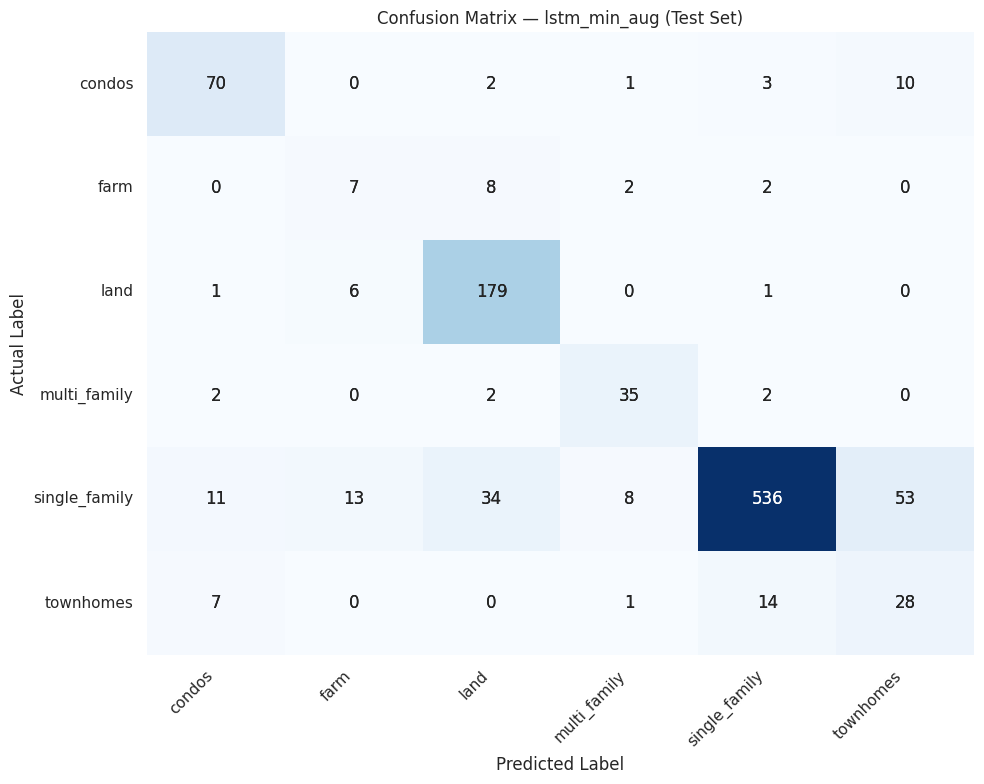

epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr,██████████▁▁▁▁
train_loss,█▆▅▄▃▃▃▂▂▂▂▁▁▁
val_acc,▁▄▆▄▅▇▇▇▇▇████
val_loss,█▇▄▃▂▁▁▂▅▃▃▃▄▅
val_macro_f1,▁▃▄▅▆▆█▇▇▇▇███
val_weighted_f1,▁▄▆▄▆▇█▇▇█████
epoch,14
lr,0.0005
train_loss,0.19402
val_acc,0.87283


[lstm_aggr_aug] Epoch 1/20
Train Loss: 1.3788 | Val Loss: 1.0304
Acc: 0.3054 | Macro F1: 0.3056 | Weighted F1: 0.3256
------------------------------------------------------------
[lstm_aggr_aug] Epoch 2/20
Train Loss: 0.9580 | Val Loss: 0.8860
Acc: 0.3969 | Macro F1: 0.4102 | Weighted F1: 0.4305
------------------------------------------------------------
[lstm_aggr_aug] Epoch 3/20
Train Loss: 0.8022 | Val Loss: 0.6904
Acc: 0.6570 | Macro F1: 0.5926 | Weighted F1: 0.7107
------------------------------------------------------------
[lstm_aggr_aug] Epoch 4/20
Train Loss: 0.6550 | Val Loss: 0.6442
Acc: 0.7572 | Macro F1: 0.6275 | Weighted F1: 0.7887
------------------------------------------------------------
[lstm_aggr_aug] Epoch 5/20
Train Loss: 0.5592 | Val Loss: 0.6493
Acc: 0.6464 | Macro F1: 0.5710 | Weighted F1: 0.6995
------------------------------------------------------------
[lstm_aggr_aug] Epoch 6/20
Train Loss: 0.4753 | Val Loss: 0.5419
Acc: 0.7139 | Macro F1: 0.6394 | Weighte

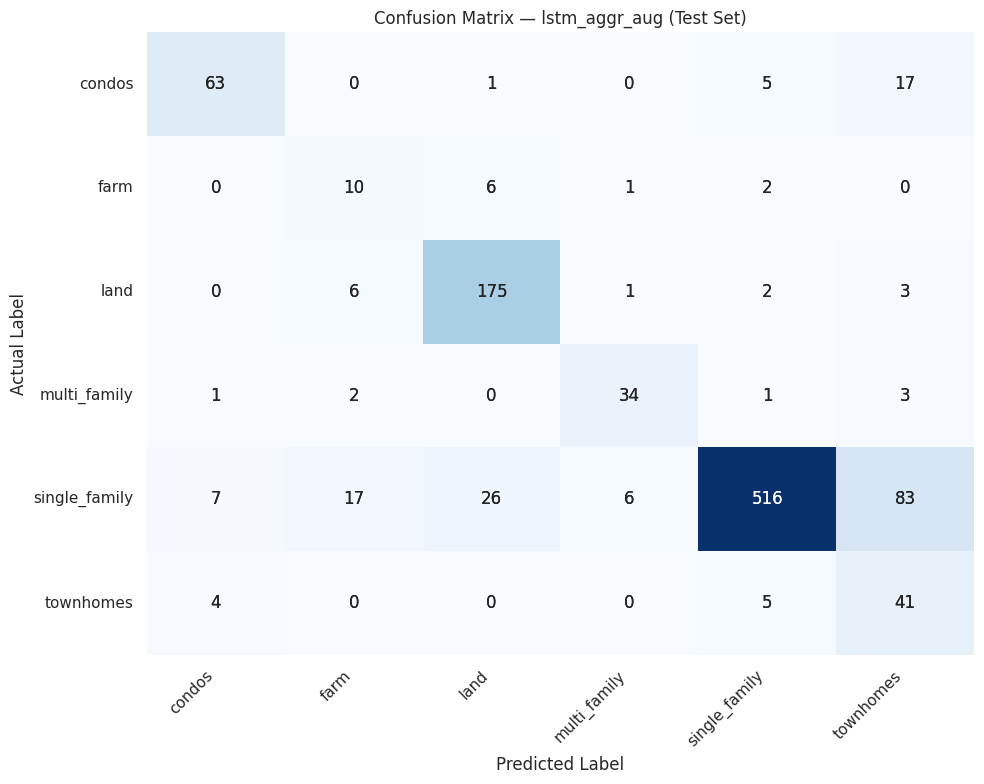

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,███████████▁▁▁▁
train_loss,█▆▅▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▂▅▇▅▆▅▇█▇▇████
val_loss,█▆▄▃▃▂▂▁▂▂▂▄▃▃▅
val_macro_f1,▁▃▆▆▅▇▇██▇█████
val_weighted_f1,▁▂▆▇▆▇▆██▇▇████
epoch,15
lr,0.0005
train_loss,0.16032
val_acc,0.82755


### Experiment Results


Results saved to: /content/DL/result_refined_ablation_20260405_084501.csv


,Model,Text,Data,Setup,Acc,Macro F1,Weighted F1,Time (s)
1,LSTM,Aggressive,Augmented,Standard,0.8083,0.6908,0.8327,47.4674
0,LSTM,Minimal,Augmented,Standard,0.8237,0.6746,0.8360,46.7111


In [ ]:
# ============================================================
# 17) Experiment Execution (Refined Ablation Matrix)
# ============================================================
display(Markdown("## 17. Running Refined Ablation Study"))
results = []
LOAD_CKPT = True
# ------------------------------------------------------------
# FAMILY 1: LSTM EXPERIMENTS
# ------------------------------------------------------------

# 1. LSTM + Minimal + Standard
lstm_vocab_min = build_vocab(train_df["text_min"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df["text_min"].tolist(), train_df["label"].tolist(), lstm_vocab_min, max_len=128), batch_size=64, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_df["text_min"].tolist(), val_df["label"].tolist(), lstm_vocab_min, max_len=128), batch_size=64)
test_loader = DataLoader(TextClassificationDataset(test_df["text_min"].tolist(), test_df["label"].tolist(), lstm_vocab_min, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, test_loader, len(lstm_vocab_min), config_name="lstm_min_std", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Minimal", "Data": "Standard", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 2. LSTM + Aggressive + Standard
lstm_vocab_aggr = build_vocab(train_df["text_aggr"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df["text_aggr"].tolist(), train_df["label"].tolist(), lstm_vocab_aggr, max_len=128), batch_size=64, shuffle=True)
val_loader = DataLoader(TextClassificationDataset(val_df["text_aggr"].tolist(), val_df["label"].tolist(), lstm_vocab_aggr, max_len=128), batch_size=64)
test_loader = DataLoader(TextClassificationDataset(test_df["text_aggr"].tolist(), test_df["label"].tolist(), lstm_vocab_aggr, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, test_loader, len(lstm_vocab_aggr), config_name="lstm_aggr_std", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Aggressive", "Data": "Standard", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 3. LSTM + Minimal + Augmented
lstm_vocab_min_aug = build_vocab(train_df_aug["text_min"].tolist(), max_size=5000)  # ← rename to avoid overwriting
train_loader = DataLoader(TextClassificationDataset(train_df_aug["text_min"].tolist(), train_df_aug["label"].tolist(), lstm_vocab_min_aug, max_len=128), batch_size=64, shuffle=True)
val_loader   = DataLoader(TextClassificationDataset(val_df["text_min"].tolist(),       val_df["label"].tolist(),       lstm_vocab_min_aug, max_len=128), batch_size=64)
test_loader  = DataLoader(TextClassificationDataset(test_df["text_min"].tolist(),      test_df["label"].tolist(),      lstm_vocab_min_aug, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, test_loader, len(lstm_vocab_min_aug), config_name="lstm_min_aug", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Minimal", "Data": "Augmented", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 4. LSTM + Aggressive + Augmented
lstm_vocab_aggr_aug = build_vocab(train_df_aug["text_aggr"].tolist(), max_size=5000)
train_loader = DataLoader(TextClassificationDataset(train_df_aug["text_aggr"].tolist(), train_df_aug["label"].tolist(), lstm_vocab_aggr_aug, max_len=128), batch_size=64, shuffle=True)
val_loader   = DataLoader(TextClassificationDataset(val_df["text_aggr"].tolist(),       val_df["label"].tolist(),       lstm_vocab_aggr_aug, max_len=128), batch_size=64)
test_loader  = DataLoader(TextClassificationDataset(test_df["text_aggr"].tolist(),      test_df["label"].tolist(),      lstm_vocab_aggr_aug, max_len=128), batch_size=64)
acc, mac_f1, weight_f1, t = train_eval_lstm(train_loader, val_loader, test_loader, len(lstm_vocab_aggr_aug), config_name="lstm_aggr_aug", epochs=20, load_ckpt=LOAD_CKPT)
results.append({"Model": "LSTM", "Text": "Aggressive", "Data": "Augmented", "Setup": "Standard", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})


# ------------------------------------------------------------
# FAMILY 2: BERT EXPERIMENTS
# ------------------------------------------------------------

# 4. BERT (Freeze) + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_frz_min_std", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Standard", "Setup": "Freeze Backbone", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 5. BERT (Freeze) + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), test_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_frz_aggr_std", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Freeze Backbone", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# BERT (Freeze) + Minimal + Augmented
# We save the model and tokenizer variables here for the Interpretability step later (Section 18)
free_bert_model, free_bert_tokenizer, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df_aug["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df_aug["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_frz_min_aug", freeze_backbone=True, epochs=8, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Augmented", "Setup": "Freeze Backbone", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})


# 6. BERT (Full) + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_full_min_std", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 7. BERT (Full) + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), test_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_full_aggr_std", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 8. BERT (Full) + Minimal + Augmented
# We save the model and tokenizer variables here for the Interpretability step later (Section 18)
full_bert_model, full_bert_tokenizer, acc, mac_f1, weight_f1, t = train_eval_transformer("bert-base-uncased", train_df_aug["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df_aug["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="bert_full_min_aug", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "BERT", "Text": "Minimal", "Data": "Augmented", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# ------------------------------------------------------------
# FAMILY 3: DISTILBERT (Efficiency Baseline)
# ------------------------------------------------------------

# # 9. DistilBERT + Minimal + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("distilbert-base-uncased", train_df["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="distil_full_min_std", freeze_backbone=False, epochs=4, load_ckpt=LOAD_CKPT)
results.append({"Model": "DistilBERT", "Text": "Minimal", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 10. DistilBERT + Aggressive + Standard
_, _, acc, mac_f1, weight_f1, t = train_eval_transformer("distilbert-base-uncased", train_df["text_aggr"].tolist(), val_df["text_aggr"].tolist(), test_df["text_aggr"].tolist(), train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="distil_full_aggr_std", freeze_backbone=False, epochs=4, load_ckpt=LOAD_CKPT)
results.append({"Model": "DistilBERT", "Text": "Aggressive", "Data": "Standard", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})

# 8. BERT (Full) + Minimal + Augmented
# We save the model and tokenizer variables here for the Interpretability step later (Section 18)
full_distillbert_model, full_disstillbert_tokenizer, acc, mac_f1, weight_f1, t = train_eval_transformer("distilbert-base-uncased", train_df_aug["text_min"].tolist(), val_df["text_min"].tolist(), test_df["text_min"].tolist(), train_df_aug["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(), config_name="distil_full_min_aug", freeze_backbone=False, epochs=5, load_ckpt=LOAD_CKPT)
results.append({"Model": "DistilBERT", "Text": "Minimal", "Data": "Augmented", "Setup": "Full Fine-tune", "Acc": acc, "Macro F1": mac_f1, "Weighted F1": weight_f1, "Time (s)": t})


# ============================================================
# Display and Save Results
# ============================================================
train_time = [54.4519, 52.1773, 60.6873, 47.4674, 4175.02, 4733.0064, 4262.0672, 3527.185, 4354.9345, 3787.7722, 1901.1171, 1877.7353, 2566.183]
results_df = pd.DataFrame(results).round(4)
display(Markdown("### Experiment Results"))

# Save CSV Results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(CKPT_DIR, f"result_refined_ablation_{timestamp}.csv")
results_df.to_csv(csv_path, index=False)
print(f"\nResults saved to: {csv_path}")
# sorted_results_df = results_df.sort_values(by=["Macro F1", "Weighted F1"], ascending=False)
display(results_df)

In [ ]:
def get_model_metrics(model):
    # Calculate parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Calculate size in MB
    # Roughly: params * 4 bytes (float32) / (1024 * 1024)
    param_size_mb = (total_params * 4) / (1024 * 1024)

    return total_params, trainable_params, round(param_size_mb, 2)

# Note: train_time was provided by the user in the context
# train_time = [54.4519, 52.1773, 60.6873, 47.4674, 4175.02, 4733.0064, 4262.0672, 3527.185, 4354.9345, 3787.7722, 1901.1171, 1877.7353, 2566.183]

# We need to map metrics to each model type used in the results
# Defining placeholders for logic to fetch metrics based on the 'Model' and 'Setup' columns
def attach_complexity_metrics(df, times):
    # Add training time
    df['Train Time (s)'] = times[:len(df)]

    params_list = []
    size_list = []

    for _, row in df.iterrows():
        m_type = row['Model']
        setup = row['Setup']

        if m_type == 'LSTM':
            # Using the config from cell L9ULupNIqxab
            temp_model = BiLSTMClassifier(5000, 128, 128, num_classes, 2, 0.4)
            p, _, s = get_model_metrics(temp_model)
        elif m_type == 'BERT':
            # bert-base-uncased approx size
            p, s = 109482240, 417.64
        elif m_type == 'DistilBERT':
            # distilbert approx size
            p, s = 66362880, 253.15
        else:
            p, s = 0, 0

        params_list.append(p)
        size_list.append(s)

    df['Total Params'] = params_list
    df['Model Size (MB)'] = size_list
    return df

results_df_extended = attach_complexity_metrics(results_df.copy(), train_time)
display(Markdown("### Refined Results with Complexity Metrics"))
display(results_df_extended)

In [ ]:
# !cp -f /content/DL/train_df_augmented.parquet /content/drive/MyDrive/University/252/DL/

## Interpretability (transformers-interpret)

In [ ]:
# Using the best fine-tuned BERT model on a sample from the test set
sample_text = test_df.iloc[0]["text_min"]
true_label = test_df.iloc[0]["type"]

# Configure model for Explainer
free_bert_model.config.id2label = id2label
free_bert_model.config.label2id = label2id

full_distillbert_model.config.id2label = id2label
full_distillbert_model.config.label2id = label2id

cls_explainer = SequenceClassificationExplainer(full_distillbert_model, full_disstillbert_tokenizer)
word_attributions = cls_explainer(sample_text)

print(f"True Label: {true_label}")
print(f"Predicted Label: {cls_explainer.predicted_class_name}")

# This will render an HTML heatmap inside the Colab output cell
html_explanation = cls_explainer.visualize()

In [ ]:
cls_explainer = SequenceClassificationExplainer(free_bert_model, free_bert_tokenizer)
word_attributions = cls_explainer(sample_text)

print(f"True Label: {true_label}")
print(f"Predicted Label: {cls_explainer.predicted_class_name}")

# This will render an HTML heatmap inside the Colab output cell
html_explanation = cls_explainer.visualize()